Using CPU
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/2
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - accuracy: 0.9423 - loss: 0.2376 - val_accuracy: 0.9785 - val_loss: 0.0715
Epoch 2/2
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 26s 10ms/step - accuracy: 0.9787 - loss: 0.0689 - val_accuracy: 0.9819 - val_loss: 0.0605
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 347ms/step
Predicted Digit : 7


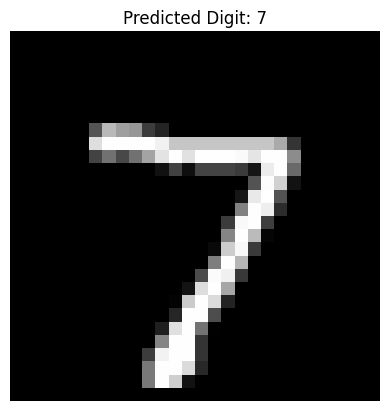

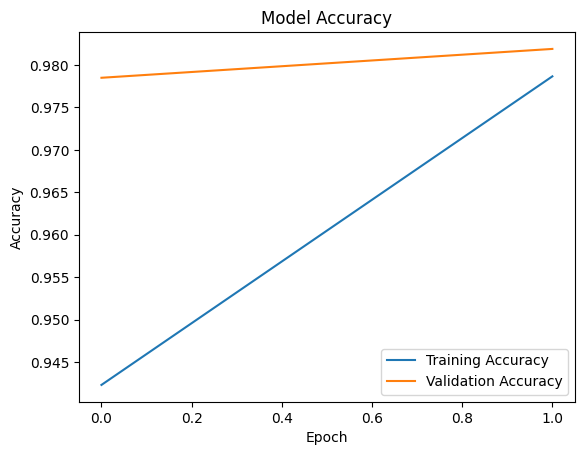

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist

print("Using CPU")
(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

model = models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(6,(5, 5), activation='relu'),
    layers.AveragePooling2D(pool_size=(2, 2)),
    layers.Conv2D(16,(5, 5), activation='relu'),
    layers.AveragePooling2D(pool_size=(2, 2)),
    layers.Flatten(),
    layers.Dense(120, activation='relu'), 
    layers.Dense(84, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model.fit(X_train, y_train, epochs=2, validation_data=(X_test, y_test))

pred = model.predict(X_test[:1])
print("Predicted Digit :", pred.argmax())

plt.imshow(X_test[0].reshape(28, 28), cmap='gray')
plt.title("Predicted Digit: "+str(pred.argmax()))
plt.axis('off') 
plt.show()

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()